# CWRU Bearing — Notebook 4: Models, Training & Results

**Prerequisite:** Run `03_preprocessing.ipynb` first.

This notebook covers:

| Section | Description |
|---------|-------------|
| 1 | Load preprocessed data |
| 2 | Classical ML baseline — SVM & Random Forest (RQ1) |
| 3 | Architecture A — 1D CNN |
| 4 | Architecture B — CNN + LSTM |
| 5 | Architecture C — CNN + Transformer |
| 6 | RQ1 results — Classical vs Deep Learning |
| 7 | RQ2 results — Architecture comparison |
| 8 | RQ3 results — Fault severity analysis |
| 9 | RQ4 results — Domain shift & fine-tuning |
| 10 | Final summary and inference demo |

---
## Section 1 — Load preprocessed data

In [3]:
import os, json, time, pickle, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import f_oneway, wilcoxon
from statsmodels.stats.multicomp import pairwise_tukeyhsd

from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score, f1_score, classification_report,
    confusion_matrix
)
from sklearn.utils.class_weight import compute_class_weight

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, callbacks

warnings.filterwarnings('ignore')
np.random.seed(42)
tf.random.set_seed(42)
plt.rcParams.update({'figure.dpi': 120, 'font.size': 11})

OUT_DIR    = 'preprocessed'
RESULTS_DIR= 'results'
os.makedirs(RESULTS_DIR, exist_ok=True)

# ── Load all preprocessed arrays ─────────────────────────────────────────────
X_train_dl = np.load(f'{OUT_DIR}/X_train_dl.npy')
X_val_dl   = np.load(f'{OUT_DIR}/X_val_dl.npy')
X_test_dl  = np.load(f'{OUT_DIR}/X_test_dl.npy')

F_train    = np.load(f'{OUT_DIR}/F_train.npy')
F_val      = np.load(f'{OUT_DIR}/F_val.npy')
F_test     = np.load(f'{OUT_DIR}/F_test.npy')

y_train    = np.load(f'{OUT_DIR}/y_train.npy')
y_val      = np.load(f'{OUT_DIR}/y_val.npy')
y_test     = np.load(f'{OUT_DIR}/y_test.npy')

meta_train = pd.read_csv(f'{OUT_DIR}/meta_train.csv')
meta_val   = pd.read_csv(f'{OUT_DIR}/meta_val.csv')
meta_test  = pd.read_csv(f'{OUT_DIR}/meta_test.csv')

with open(f'{OUT_DIR}/class_info.json') as f:
    ci = json.load(f)

ALL_LABELS       = ci['all_labels']
label2idx        = ci['label2idx']
NUM_CLASSES      = ci['num_classes']
FEATURE_NAMES    = ci['feature_names']
class_weight_dict= {int(k): v for k, v in ci['class_weight_dict'].items()}
WINDOW           = ci['window_size']

print('Data loaded successfully.')
print(f'  Train: {X_train_dl.shape}  Val: {X_val_dl.shape}  Test: {X_test_dl.shape}')
print(f'  Classical features: {F_train.shape[1]} per segment')
print(f'  Classes: {NUM_CLASSES} → {ALL_LABELS}')

2026-05-09 17:37:46.896477: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


Data loaded successfully.
  Train: (8510, 1024, 1)  Val: (4494, 1024, 1)  Test: (4499, 1024, 1)
  Classical features: 14 per segment
  Classes: 16 → ['Normal', 'IR_7', 'IR_14', 'IR_21', 'IR_28', 'Ball_7', 'Ball_14', 'Ball_21', 'Ball_28', 'OR@6_7', 'OR@6_14', 'OR@6_21', 'OR@3_7', 'OR@3_21', 'OR@12_7', 'OR@12_21']


---
## Section 2 — Classical ML Baseline (RQ1)
### SVM and Random Forest on hand-crafted features

In [4]:
results = {}   # accumulate all model results

# ── Random Forest ─────────────────────────────────────────────────────────────
print('Training Random Forest...')
t0 = time.time()
rf = RandomForestClassifier(
    n_estimators=200,
    max_features='sqrt',
    class_weight='balanced',
    random_state=42,
    n_jobs=-1
)
rf.fit(F_train, y_train)
rf_time = time.time() - t0
rf_pred = rf.predict(F_test)

results['Random Forest'] = {
    'acc':    accuracy_score(y_test, rf_pred),
    'f1':     f1_score(y_test, rf_pred, average='macro'),
    'pred':   rf_pred,
    'params': 'N/A',
    'time_s': rf_time
}
print(f'  RF  → Accuracy={results["Random Forest"]["acc"]:.4f}  Macro F1={results["Random Forest"]["f1"]:.4f}')

# ── SVM ───────────────────────────────────────────────────────────────────────
print('Training SVM (may take several minutes)...')
t0 = time.time()
svm = SVC(
    kernel='rbf',
    C=10,
    gamma='scale',
    class_weight='balanced',
    random_state=42
)
svm.fit(F_train, y_train)
svm_time = time.time() - t0
svm_pred = svm.predict(F_test)

results['SVM'] = {
    'acc':    accuracy_score(y_test, svm_pred),
    'f1':     f1_score(y_test, svm_pred, average='macro'),
    'pred':   svm_pred,
    'params': 'N/A',
    'time_s': svm_time
}
print(f'  SVM → Accuracy={results["SVM"]["acc"]:.4f}  Macro F1={results["SVM"]["f1"]:.4f}')

Training Random Forest...
  RF  → Accuracy=0.9335  Macro F1=0.9167
Training SVM (may take several minutes)...
  SVM → Accuracy=0.9275  Macro F1=0.9166


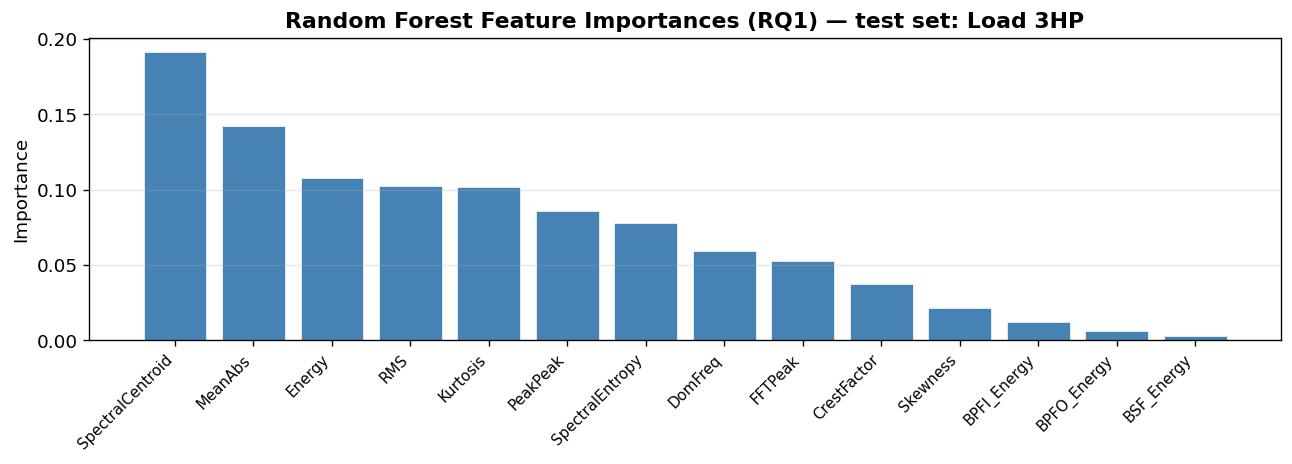

Saved: rq1_feature_importance.png


In [5]:
# ── Random Forest feature importance plot ─────────────────────────────────────
importances = rf.feature_importances_
order = np.argsort(importances)[::-1]

fig, ax = plt.subplots(figsize=(11, 4))
ax.bar(range(len(importances)), importances[order],
       color='steelblue', edgecolor='white', linewidth=0.4)
ax.set_xticks(range(len(importances)))
ax.set_xticklabels([FEATURE_NAMES[i] for i in order], rotation=45, ha='right', fontsize=9)
ax.set_ylabel('Importance')
ax.set_title('Random Forest Feature Importances (RQ1) — test set: Load 3HP', fontweight='bold')
ax.grid(True, alpha=0.3, axis='y')
plt.tight_layout()
plt.savefig(f'{RESULTS_DIR}/rq1_feature_importance.png', bbox_inches='tight')
plt.show()
print('Saved: rq1_feature_importance.png')

---
## Section 3 — Architecture A: 1D CNN
### Baseline deep learning model — raw signal input

In [6]:
def build_cnn(input_shape=(WINDOW, 1), num_classes=NUM_CLASSES):
    """
    1D CNN: 4 convolutional layers with BatchNorm + MaxPool,
    GlobalAveragePooling, two Dense layers with Dropout.
    Input: (batch, 1024, 1) — raw normalised signal.
    """
    inp = keras.Input(shape=input_shape, name='signal_input')
    x = layers.Conv1D(32,  16, padding='same', activation='relu', name='conv1')(inp)
    x = layers.BatchNormalization()(x)
    x = layers.MaxPooling1D(2)(x)

    x = layers.Conv1D(64,  16, padding='same', activation='relu', name='conv2')(x)
    x = layers.BatchNormalization()(x)
    x = layers.MaxPooling1D(2)(x)

    x = layers.Conv1D(128, 8,  padding='same', activation='relu', name='conv3')(x)
    x = layers.BatchNormalization()(x)
    x = layers.MaxPooling1D(2)(x)

    x = layers.Conv1D(256, 8,  padding='same', activation='relu', name='conv4')(x)
    x = layers.BatchNormalization()(x)
    x = layers.GlobalAveragePooling1D()(x)

    x = layers.Dense(256, activation='relu')(x)
    x = layers.Dropout(0.3)(x)
    x = layers.Dense(128, activation='relu')(x)
    x = layers.Dropout(0.3)(x)
    out = layers.Dense(num_classes, activation='softmax', name='output')(x)

    model = keras.Model(inp, out, name='1D_CNN')
    model.compile(
        optimizer=keras.optimizers.Adam(1e-3),
        loss='sparse_categorical_crossentropy',
        metrics=['accuracy']
    )
    return model

def get_callbacks(monitor='val_loss'):
    return [
        callbacks.EarlyStopping(monitor=monitor, patience=10, restore_best_weights=True, verbose=0),
        callbacks.ReduceLROnPlateau(monitor=monitor, factor=0.5, patience=5, min_lr=1e-5, verbose=0)
    ]

cnn_model = build_cnn()
cnn_model.summary()

print('\nTraining 1D CNN...')
t0 = time.time()
hist_cnn = cnn_model.fit(
    X_train_dl, y_train,
    validation_data=(X_val_dl, y_val),
    epochs=60, batch_size=128,
    class_weight=class_weight_dict,
    callbacks=get_callbacks(),
    verbose=1
)
cnn_train_time = time.time() - t0
print(f'Done in {cnn_train_time:.1f}s')

I0000 00:00:1778328480.919635   97157 gpu_device.cc:2020] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 21405 MB memory:  -> device: 0, name: NVIDIA GeForce RTX 3090, pci bus id: 0000:2d:00.0, compute capability: 8.6


Model: "1D_CNN"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ signal_input (InputLayer)       │ (None, 1024, 1)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1 (Conv1D)                  │ (None, 1024, 32)       │           544 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 1024, 32)       │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d (MaxPooling1D)    │ (None, 512, 32)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2 (Conv1D)                  │ (None, 512, 64)        │        32,832 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 512, 64)        │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_1 (MaxPooling1D)  │ (None, 256, 64)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv3 (Conv1D)                  │ (None, 256, 128)       │        65,664 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 256, 128)       │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_2 (MaxPooling1D)  │ (None, 128, 128)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv4 (Conv1D)                  │ (None, 128, 256)       │       262,400 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 128, 256)       │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling1d        │ (None, 256)            │             0 │
│ (GlobalAveragePooling1D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │        65,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output (Dense)                  │ (None, 16)             │         2,064 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 464,112 (1.77 MB)

 Trainable params: 463,152 (1.77 MB)

...

64/67 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.7398 - loss: 0.9368

2026-05-09 17:38:09.456951: I external/local_xla/xla/service/gpu/autotuning/dot_search_space.cc:208] All configs were filtered out because none of them sufficiently match the hints. Maybe the hints set does not contain a good representative set of valid configs? Working around this by using the full hints set instead.
2026-05-09 17:38:09.456971: I external/local_xla/xla/service/gpu/autotuning/dot_search_space.cc:208] All configs were filtered out because none of them sufficiently match the hints. Maybe the hints set does not contain a good representative set of valid configs? Working around this by using the full hints set instead.
2026-05-09 17:38:09.456997: I external/local_xla/xla/service/gpu/autotuning/dot_search_space.cc:208] All configs were filtered out because none of them sufficiently match the hints. Maybe the hints set does not contain a good representative set of valid configs? Working around this by using the full hints set instead.
2026-05-09 17:38:09.457007: I external/l

67/67 ━━━━━━━━━━━━━━━━━━━━ 0s 88ms/step - accuracy: 0.7469 - loss: 0.9115

2026-05-09 17:38:14.737438: I external/local_xla/xla/service/gpu/autotuning/dot_search_space.cc:208] All configs were filtered out because none of them sufficiently match the hints. Maybe the hints set does not contain a good representative set of valid configs? Working around this by using the full hints set instead.
2026-05-09 17:38:14.937308: I external/local_xla/xla/stream_executor/cuda/subprocess_compilation.cc:346] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_dot_183', 8 bytes spill stores, 8 bytes spill loads

2026-05-09 17:38:16.201948: I external/local_xla/xla/stream_executor/cuda/subprocess_compilation.cc:346] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_dot_183', 8 bytes spill stores, 8 bytes spill loads



67/67 ━━━━━━━━━━━━━━━━━━━━ 15s 123ms/step - accuracy: 0.8992 - loss: 0.3692 - val_accuracy: 0.0550 - val_loss: 5.6809 - learning_rate: 0.0010
Epoch 2/60
67/67 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - accuracy: 0.9954 - loss: 0.0181 - val_accuracy: 0.0926 - val_loss: 9.8276 - learning_rate: 0.0010
Epoch 3/60
67/67 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - accuracy: 0.9985 - loss: 0.0079 - val_accuracy: 0.1086 - val_loss: 9.7220 - learning_rate: 0.0010
Epoch 4/60
67/67 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - accuracy: 0.9952 - loss: 0.0176 - val_accuracy: 0.1733 - val_loss: 7.4236 - learning_rate: 0.0010
Epoch 5/60
67/67 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - accuracy: 0.9979 - loss: 0.0088 - val_accuracy: 0.3520 - val_loss: 4.4627 - learning_rate: 0.0010
Epoch 6/60
67/67 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - accuracy: 0.9993 - loss: 0.0023 - val_accuracy: 0.8387 - val_loss: 1.5489 - learning_rate: 0.0010
Epoch 7/60
67/67 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - accuracy: 1.0000 - loss: 8.8603e-04 - val_accuracy: 0.91

---
## Section 4 — Architecture B: CNN + LSTM

In [7]:
def build_cnn_lstm(input_shape=(WINDOW, 1), num_classes=NUM_CLASSES):
    """
    CNN stem extracts local frequency features.
    Bidirectional LSTM captures temporal dependencies across the window.
    """
    inp = keras.Input(shape=input_shape)
    x = layers.Conv1D(64, 16, padding='same', activation='relu')(inp)
    x = layers.BatchNormalization()(x)
    x = layers.MaxPooling1D(2)(x)
    x = layers.Conv1D(128, 8, padding='same', activation='relu')(x)
    x = layers.BatchNormalization()(x)
    x = layers.MaxPooling1D(2)(x)
    x = layers.Bidirectional(layers.LSTM(64, return_sequences=True))(x)
    x = layers.Bidirectional(layers.LSTM(64))(x)
    x = layers.Dense(128, activation='relu')(x)
    x = layers.Dropout(0.3)(x)
    out = layers.Dense(num_classes, activation='softmax')(x)
    model = keras.Model(inp, out, name='CNN_LSTM')
    model.compile(optimizer=keras.optimizers.Adam(1e-3),
                  loss='sparse_categorical_crossentropy', metrics=['accuracy'])
    return model

lstm_model = build_cnn_lstm()
print('Training CNN+LSTM...')
t0 = time.time()
hist_lstm = lstm_model.fit(
    X_train_dl, y_train,
    validation_data=(X_val_dl, y_val),
    epochs=60, batch_size=128,
    class_weight=class_weight_dict,
    callbacks=get_callbacks(),
    verbose=1
)
lstm_train_time = time.time() - t0
print(f'Done in {lstm_train_time:.1f}s')

Training CNN+LSTM...
Epoch 1/60
67/67 ━━━━━━━━━━━━━━━━━━━━ 7s 51ms/step - accuracy: 0.7336 - loss: 0.9940 - val_accuracy: 0.1785 - val_loss: 2.4814 - learning_rate: 0.0010
Epoch 2/60
67/67 ━━━━━━━━━━━━━━━━━━━━ 3s 43ms/step - accuracy: 0.9427 - loss: 0.1643 - val_accuracy: 0.1320 - val_loss: 2.5546 - learning_rate: 0.0010
Epoch 3/60
67/67 ━━━━━━━━━━━━━━━━━━━━ 3s 42ms/step - accuracy: 0.9434 - loss: 0.1629 - val_accuracy: 0.2034 - val_loss: 2.3094 - learning_rate: 0.0010
Epoch 4/60
67/67 ━━━━━━━━━━━━━━━━━━━━ 3s 42ms/step - accuracy: 0.9828 - loss: 0.0643 - val_accuracy: 0.2410 - val_loss: 2.2352 - learning_rate: 0.0010
Epoch 5/60
67/67 ━━━━━━━━━━━━━━━━━━━━ 3s 42ms/step - accuracy: 0.9961 - loss: 0.0221 - val_accuracy: 0.4117 - val_loss: 2.1235 - learning_rate: 0.0010
Epoch 6/60
67/67 ━━━━━━━━━━━━━━━━━━━━ 3s 42ms/step - accuracy: 0.9899 - loss: 0.0442 - val_accuracy: 0.7641 - val_loss: 0.8636 - learning_rate: 0.0010
Epoch 7/60
67/67 ━━━━━━━━━━━━━━━━━━━━ 3s 42ms/step - accuracy: 0.9921 - l

---
## Section 5 — Architecture C: CNN + Transformer

In [8]:
def transformer_encoder_block(x, num_heads=4, key_dim=64, ff_dim=256, dropout=0.1):
    """Single Transformer encoder block: multi-head self-attention + feed-forward."""
    attn = layers.MultiHeadAttention(num_heads=num_heads, key_dim=key_dim, dropout=dropout)(x, x)
    attn = layers.Dropout(dropout)(attn)
    x1   = layers.LayerNormalization(epsilon=1e-6)(x + attn)
    ff   = layers.Dense(ff_dim, activation='relu')(x1)
    ff   = layers.Dropout(dropout)(ff)
    ff   = layers.Dense(x1.shape[-1])(ff)
    return layers.LayerNormalization(epsilon=1e-6)(x1 + ff)

def build_cnn_transformer(input_shape=(WINDOW, 1), num_classes=NUM_CLASSES):
    """
    CNN encodes the signal into patch embeddings.
    Two Transformer encoder blocks apply self-attention over the full window.
    Self-attention allows the model to relate any two positions in the signal,
    unlike CNN (local receptive field) or LSTM (sequential dependency only).
    """
    inp = keras.Input(shape=input_shape)
    x = layers.Conv1D(128, 8, padding='same', activation='relu')(inp)
    x = layers.BatchNormalization()(x)
    x = layers.MaxPooling1D(4)(x)          # 1024 → 256
    x = layers.Conv1D(128, 4, padding='same', activation='relu')(x)
    x = layers.BatchNormalization()(x)
    x = layers.MaxPooling1D(4)(x)          # 256 → 64
    x = transformer_encoder_block(x)
    x = transformer_encoder_block(x)
    x = layers.GlobalAveragePooling1D()(x)
    x = layers.Dense(128, activation='relu')(x)
    x = layers.Dropout(0.3)(x)
    out = layers.Dense(num_classes, activation='softmax')(x)
    model = keras.Model(inp, out, name='CNN_Transformer')
    model.compile(optimizer=keras.optimizers.Adam(1e-3),
                  loss='sparse_categorical_crossentropy', metrics=['accuracy'])
    return model

transformer_model = build_cnn_transformer()
print('Training CNN+Transformer...')
t0 = time.time()
hist_trans = transformer_model.fit(
    X_train_dl, y_train,
    validation_data=(X_val_dl, y_val),
    epochs=60, batch_size=128,
    class_weight=class_weight_dict,
    callbacks=get_callbacks(),
    verbose=1
)
trans_train_time = time.time() - t0
print(f'Done in {trans_train_time:.1f}s')

Training CNN+Transformer...
Epoch 1/60


2026-05-09 18:03:59.825818: I external/local_xla/xla/service/gpu/autotuning/dot_search_space.cc:208] All configs were filtered out because none of them sufficiently match the hints. Maybe the hints set does not contain a good representative set of valid configs? Working around this by using the full hints set instead.
2026-05-09 18:03:59.825844: I external/local_xla/xla/service/gpu/autotuning/dot_search_space.cc:208] All configs were filtered out because none of them sufficiently match the hints. Maybe the hints set does not contain a good representative set of valid configs? Working around this by using the full hints set instead.
2026-05-09 18:03:59.826200: I external/local_xla/xla/service/gpu/autotuning/dot_search_space.cc:208] All configs were filtered out because none of them sufficiently match the hints. Maybe the hints set does not contain a good representative set of valid configs? Working around this by using the full hints set instead.
2026-05-09 18:04:00.499987: I external/l

66/67 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.7075 - loss: 1.0808

2026-05-09 18:04:10.943212: I external/local_xla/xla/service/gpu/autotuning/dot_search_space.cc:208] All configs were filtered out because none of them sufficiently match the hints. Maybe the hints set does not contain a good representative set of valid configs? Working around this by using the full hints set instead.
2026-05-09 18:04:10.943239: I external/local_xla/xla/service/gpu/autotuning/dot_search_space.cc:208] All configs were filtered out because none of them sufficiently match the hints. Maybe the hints set does not contain a good representative set of valid configs? Working around this by using the full hints set instead.
2026-05-09 18:04:10.943552: I external/local_xla/xla/service/gpu/autotuning/dot_search_space.cc:208] All configs were filtered out because none of them sufficiently match the hints. Maybe the hints set does not contain a good representative set of valid configs? Working around this by using the full hints set instead.
2026-05-09 18:04:11.997361: I external/l

67/67 ━━━━━━━━━━━━━━━━━━━━ 27s 210ms/step - accuracy: 0.8736 - loss: 0.5025 - val_accuracy: 0.1449 - val_loss: 4.8670 - learning_rate: 0.0010
Epoch 2/60
67/67 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - accuracy: 0.9940 - loss: 0.0373 - val_accuracy: 0.1041 - val_loss: 6.6136 - learning_rate: 0.0010
Epoch 3/60
67/67 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - accuracy: 0.9918 - loss: 0.0397 - val_accuracy: 0.2911 - val_loss: 3.1383 - learning_rate: 0.0010
Epoch 4/60
67/67 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - accuracy: 0.9993 - loss: 0.0057 - val_accuracy: 0.5098 - val_loss: 2.1111 - learning_rate: 0.0010
Epoch 5/60
67/67 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - accuracy: 0.9982 - loss: 0.0078 - val_accuracy: 0.7165 - val_loss: 1.4367 - learning_rate: 0.0010
Epoch 6/60
67/67 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - accuracy: 0.9986 - loss: 0.0082 - val_accuracy: 0.8554 - val_loss: 0.6869 - learning_rate: 0.0010
Epoch 7/60
67/67 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - accuracy: 0.9987 - loss: 0.0059 - val_accuracy: 0.

---
## Section 6 — RQ1: Classical vs Deep Learning
### Does end-to-end DL outperform hand-crafted features?

2026-05-09 18:05:21.810543: I external/local_xla/xla/service/gpu/autotuning/dot_search_space.cc:208] All configs were filtered out because none of them sufficiently match the hints. Maybe the hints set does not contain a good representative set of valid configs? Working around this by using the full hints set instead.
2026-05-09 18:05:21.810568: I external/local_xla/xla/service/gpu/autotuning/dot_search_space.cc:208] All configs were filtered out because none of them sufficiently match the hints. Maybe the hints set does not contain a good representative set of valid configs? Working around this by using the full hints set instead.
2026-05-09 18:05:22.452908: I external/local_xla/xla/stream_executor/cuda/subprocess_compilation.cc:346] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_dot_170', 4 bytes spill stores, 4 bytes spill loads

2026-05-09 18:05:22.680472: I external/local_xla/xla/stream_executor/cuda/subprocess_compilation.cc:346] ptxas warning : Re


=== RQ1 & RQ2 Model Comparison (Test = Load 3HP) ===
          Model  Accuracy  Macro F1 Parameters  Latency (ms)
  Random Forest  0.933541  0.916736        N/A           NaN
            SVM  0.927539  0.916595        N/A           NaN
         1D CNN  0.888864  0.849322     464112     42.884979
       CNN+LSTM  0.851300  0.809000     283728     47.321446
CNN+Transformer  0.969549  0.963638     483216     80.088005


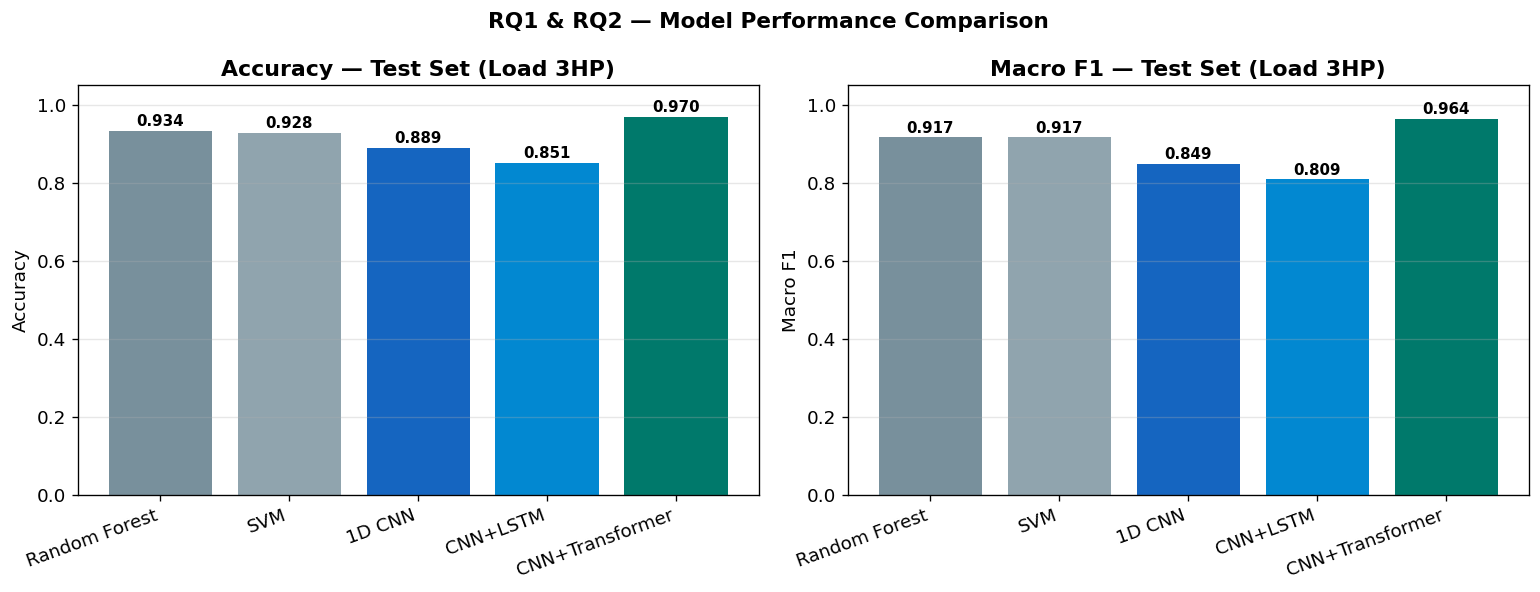

In [9]:
def measure_latency(model, X, n=100):
    sample = X[:1]
    t0 = time.time()
    for _ in range(n): model.predict(sample, verbose=0)
    return (time.time() - t0) / n * 1000

# Get DL predictions
cnn_pred   = np.argmax(cnn_model.predict(X_test_dl, verbose=0), axis=1)
lstm_pred  = np.argmax(lstm_model.predict(X_test_dl, verbose=0), axis=1)
trans_pred = np.argmax(transformer_model.predict(X_test_dl, verbose=0), axis=1)

# Compile all results
results['SVM']['latency_ms']              = None
results['Random Forest']['latency_ms']    = None
results['1D CNN'] = {
    'acc':        accuracy_score(y_test, cnn_pred),
    'f1':         f1_score(y_test, cnn_pred, average='macro'),
    'pred':       cnn_pred,
    'params':     cnn_model.count_params(),
    'latency_ms': measure_latency(cnn_model, X_test_dl)
}
results['CNN+LSTM'] = {
    'acc':        accuracy_score(y_test, lstm_pred),
    'f1':         f1_score(y_test, lstm_pred, average='macro'),
    'pred':       lstm_pred,
    'params':     lstm_model.count_params(),
    'latency_ms': measure_latency(lstm_model, X_test_dl)
}
results['CNN+Transformer'] = {
    'acc':        accuracy_score(y_test, trans_pred),
    'f1':         f1_score(y_test, trans_pred, average='macro'),
    'pred':       trans_pred,
    'params':     transformer_model.count_params(),
    'latency_ms': measure_latency(transformer_model, X_test_dl)
}

df_results = pd.DataFrame([
    {'Model': k, 'Accuracy': v['acc'], 'Macro F1': v['f1'],
     'Parameters': v['params'], 'Latency (ms)': v.get('latency_ms')}
    for k, v in results.items()
])

print('\n=== RQ1 & RQ2 Model Comparison (Test = Load 3HP) ===')
print(df_results.to_string(index=False))
df_results.to_csv(f'{RESULTS_DIR}/model_comparison.csv', index=False)

# ── Bar chart ─────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
model_names = list(results.keys())
colors = ['#78909C','#90A4AE','#1565C0','#0288D1','#00796B']

for ax, metric in zip(axes, ['Accuracy', 'Macro F1']):
    vals = df_results[metric].tolist()
    bars = ax.bar(model_names, vals, color=colors[:len(model_names)])
    ax.set_ylim(0, 1.05)
    ax.set_title(f'{metric} — Test Set (Load 3HP)', fontweight='bold')
    ax.set_ylabel(metric)
    ax.set_xticklabels(model_names, rotation=20, ha='right')
    ax.grid(True, alpha=0.3, axis='y')
    for bar, val in zip(bars, vals):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height()+0.005,
                f'{val:.3f}', ha='center', va='bottom', fontsize=9, fontweight='bold')

plt.suptitle('RQ1 & RQ2 — Model Performance Comparison', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(f'{RESULTS_DIR}/rq1_rq2_comparison.png', bbox_inches='tight')
plt.show()

---
## Section 7 — RQ2: Architecture Comparison + Training Curves

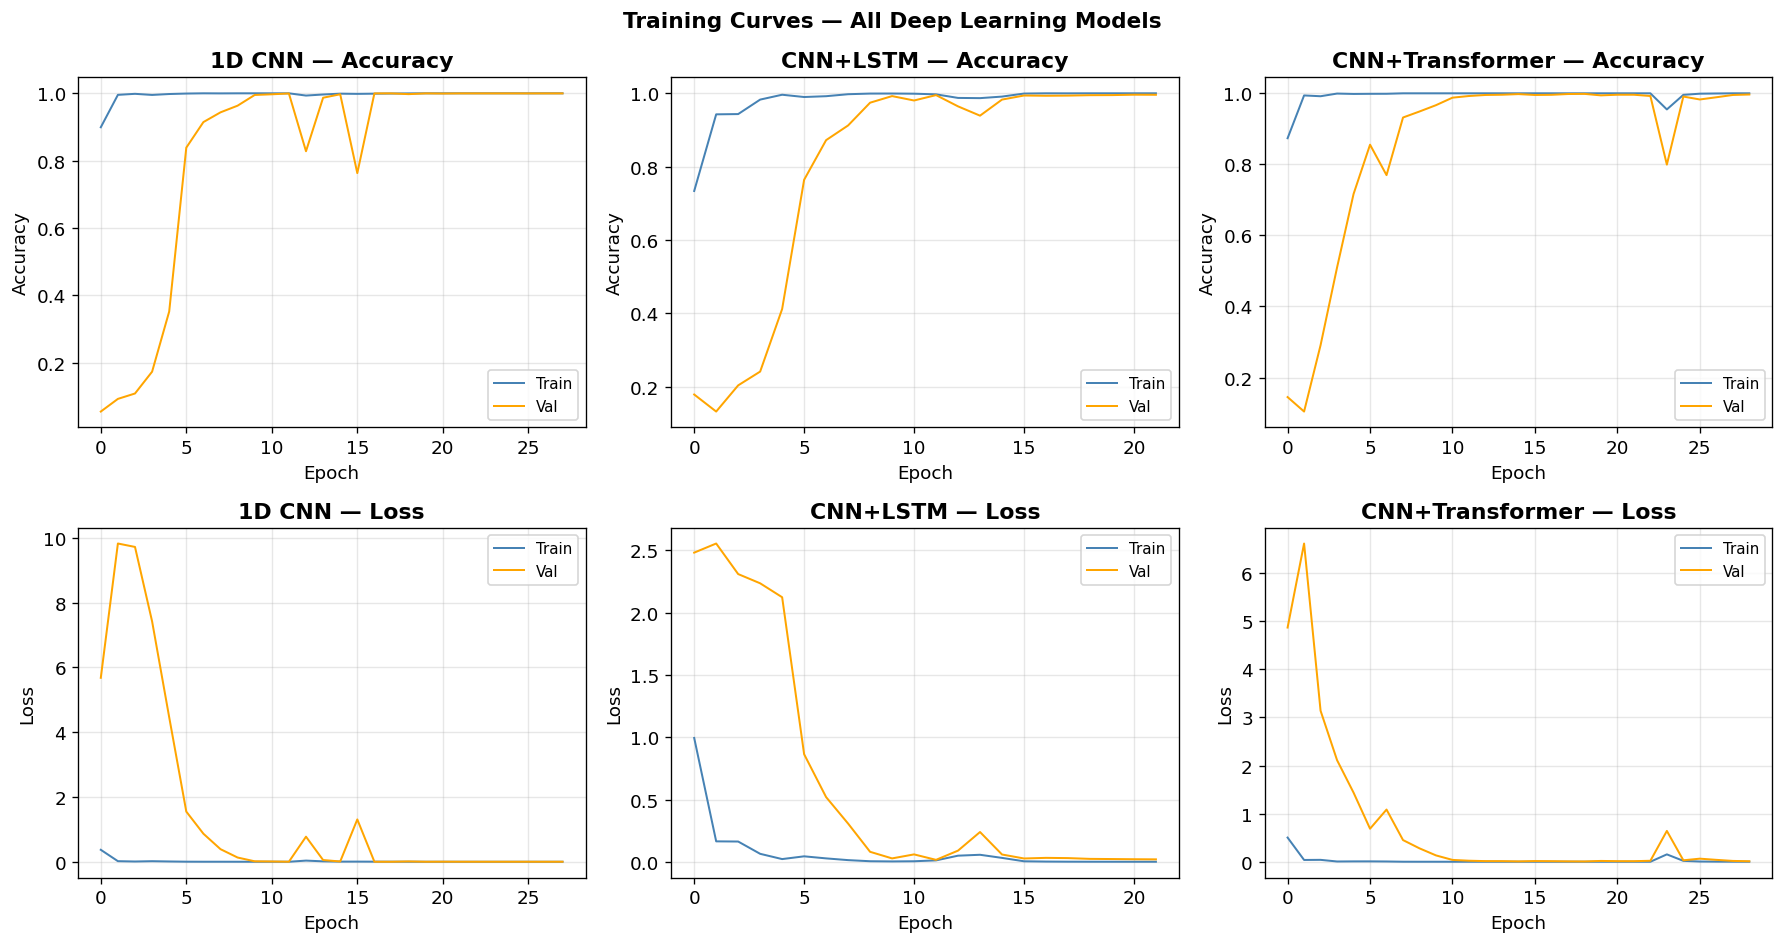

In [10]:
# ── Training curves ───────────────────────────────────────────────────────────
fig, axes = plt.subplots(2, 3, figsize=(15, 8))
hists = [('1D CNN', hist_cnn), ('CNN+LSTM', hist_lstm), ('CNN+Transformer', hist_trans)]

for col, (name, hist) in enumerate(hists):
    axes[0][col].plot(hist.history['accuracy'],     label='Train', color='steelblue', linewidth=1.2)
    axes[0][col].plot(hist.history['val_accuracy'], label='Val',   color='orange',    linewidth=1.2)
    axes[0][col].set_title(f'{name} — Accuracy', fontweight='bold')
    axes[0][col].set_ylabel('Accuracy')
    axes[0][col].set_xlabel('Epoch')
    axes[0][col].legend(fontsize=9)
    axes[0][col].grid(True, alpha=0.3)

    axes[1][col].plot(hist.history['loss'],     label='Train', color='steelblue', linewidth=1.2)
    axes[1][col].plot(hist.history['val_loss'], label='Val',   color='orange',    linewidth=1.2)
    axes[1][col].set_title(f'{name} — Loss', fontweight='bold')
    axes[1][col].set_ylabel('Loss')
    axes[1][col].set_xlabel('Epoch')
    axes[1][col].legend(fontsize=9)
    axes[1][col].grid(True, alpha=0.3)

plt.suptitle('Training Curves — All Deep Learning Models', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(f'{RESULTS_DIR}/training_curves.png', bbox_inches='tight')
plt.show()

Best DL model: CNN+Transformer  (Macro F1 = 0.9636)


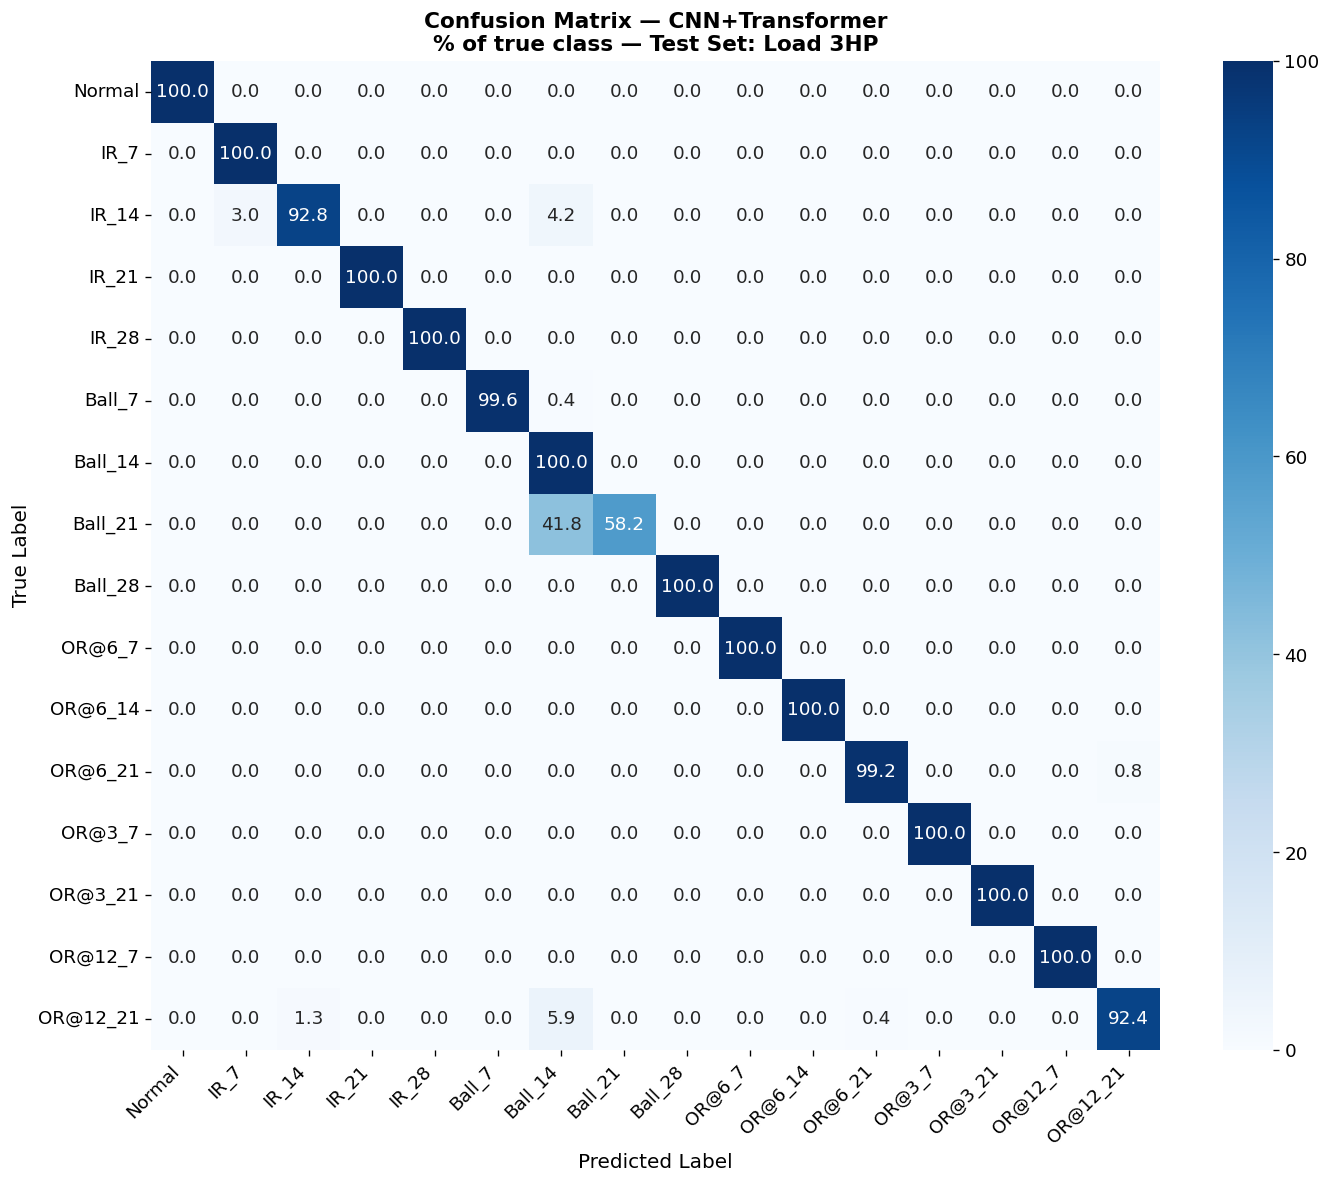


Classification Report:
              precision    recall  f1-score   support

      Normal       1.00      1.00      1.00       947
        IR_7       0.97      1.00      0.99       239
       IR_14       0.99      0.93      0.96       236
       IR_21       1.00      1.00      1.00       237
       IR_28       1.00      1.00      1.00       236
      Ball_7       1.00      1.00      1.00       236
     Ball_14       0.66      1.00      0.79       237
     Ball_21       1.00      0.58      0.74       237
     Ball_28       1.00      1.00      1.00       235
      OR@6_7       1.00      1.00      1.00       238
     OR@6_14       1.00      1.00      1.00       237
     OR@6_21       1.00      0.99      0.99       237
      OR@3_7       1.00      1.00      1.00       237
     OR@3_21       1.00      1.00      1.00       237
     OR@12_7       1.00      1.00      1.00       237
    OR@12_21       0.99      0.92      0.96       236

    accuracy                           0.97      4499
  

In [11]:
# ── RQ2: Best model confusion matrix ─────────────────────────────────────────
dl_models = {k: v for k, v in results.items() if k not in ['SVM','Random Forest']}
best_name = max(dl_models, key=lambda k: dl_models[k]['f1'])
best_pred = dl_models[best_name]['pred']
print(f'Best DL model: {best_name}  (Macro F1 = {dl_models[best_name]["f1"]:.4f})')

cm     = confusion_matrix(y_test, best_pred)
cm_pct = cm.astype(float) / cm.sum(axis=1, keepdims=True) * 100

fig, ax = plt.subplots(figsize=(12, 10))
sns.heatmap(cm_pct, annot=True, fmt='.1f', cmap='Blues',
            xticklabels=ALL_LABELS, yticklabels=ALL_LABELS, ax=ax)
ax.set_xlabel('Predicted Label', fontsize=12)
ax.set_ylabel('True Label', fontsize=12)
ax.set_title(f'Confusion Matrix — {best_name}\n% of true class — Test Set: Load 3HP',
             fontsize=13, fontweight='bold')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.savefig(f'{RESULTS_DIR}/rq2_confusion_matrix.png', bbox_inches='tight')
plt.show()

print('\nClassification Report:')
print(classification_report(y_test, best_pred, target_names=ALL_LABELS))

---
## Section 8 — RQ3: Fault Severity Analysis

=== RQ3: Per-class Accuracy by Severity ===
   Label  Severity (mils)  Accuracy  Count
  Normal                0  1.000000    947
    IR_7                7  1.000000    239
   IR_14               14  0.927966    236
   IR_21               21  1.000000    237
   IR_28               28  1.000000    236
  Ball_7                7  0.995763    236
 Ball_14               14  1.000000    237
 Ball_21               21  0.582278    237
 Ball_28               28  1.000000    235
  OR@6_7                7  1.000000    238
 OR@6_14               14  1.000000    237
 OR@6_21               21  0.991561    237
  OR@3_7                7  1.000000    237
 OR@3_21               21  1.000000    237
 OR@12_7                7  1.000000    237
OR@12_21               21  0.923729    236


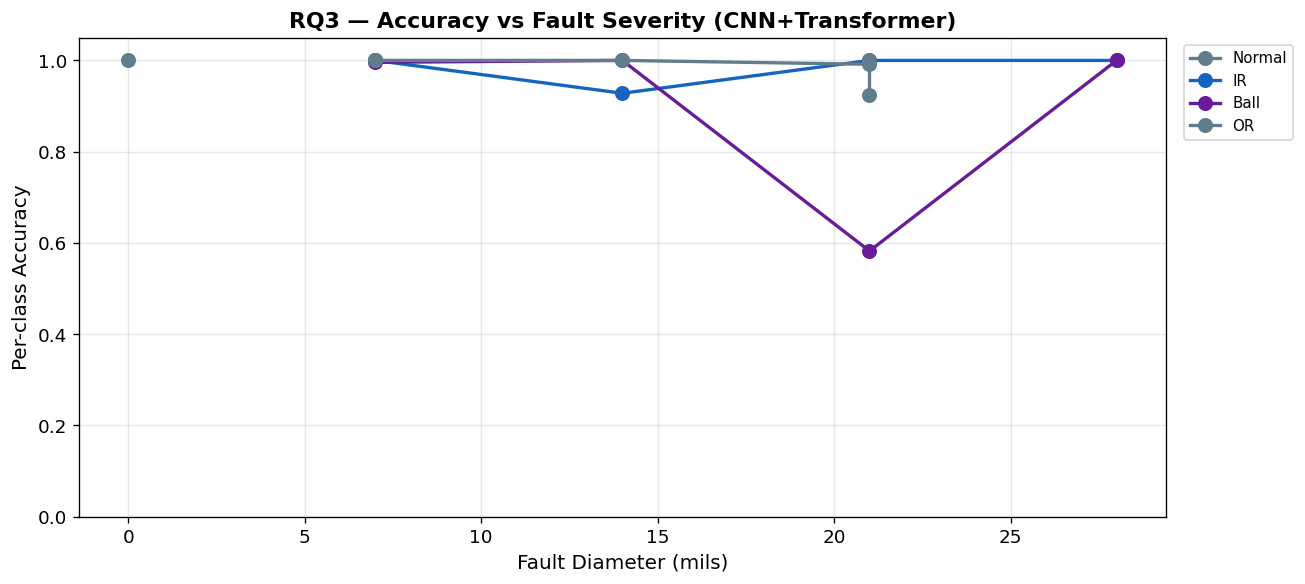

In [12]:
# Per-class accuracy broken down by fault type and severity
sev_rows = []
for idx, lbl in enumerate(ALL_LABELS):
    mask = y_test == idx
    if mask.sum() == 0: continue
    acc = accuracy_score(y_test[mask], best_pred[mask])
    parts = lbl.split('_')
    fault_type = parts[0].replace('@6','').replace('@3','').replace('@12','')
    severity   = int(parts[-1]) if len(parts) > 1 else 0
    sev_rows.append({
        'Label': lbl, 'Fault Type': fault_type,
        'OR Position': parts[0] if 'OR' in parts[0] else None,
        'Severity (mils)': severity,
        'Accuracy': acc, 'Count': int(mask.sum())
    })

df_sev = pd.DataFrame(sev_rows)
print('=== RQ3: Per-class Accuracy by Severity ===')
print(df_sev[['Label','Severity (mils)','Accuracy','Count']].to_string(index=False))
df_sev.to_csv(f'{RESULTS_DIR}/rq3_severity.csv', index=False)

# Plot
fig, ax = plt.subplots(figsize=(11, 5))
fault_colors = {'IR': '#1565C0', 'OR@6': '#E65100', 'OR@3': '#FF8F00',
                'OR@12': '#FFC107', 'Ball': '#6A1B9A', 'Normal': '#607D8B'}

for ft in df_sev['Fault Type'].unique():
    sub = df_sev[df_sev['Fault Type']==ft].sort_values('Severity (mils)')
    ax.plot(sub['Severity (mils)'], sub['Accuracy'],
            marker='o', linewidth=2, markersize=8,
            label=ft, color=fault_colors.get(ft, '#607D8B'))

ax.set_xlabel('Fault Diameter (mils)', fontsize=12)
ax.set_ylabel('Per-class Accuracy', fontsize=12)
ax.set_title(f'RQ3 — Accuracy vs Fault Severity ({best_name})', fontweight='bold')
ax.set_ylim(0, 1.05)
ax.legend(bbox_to_anchor=(1.01, 1), loc='upper left', fontsize=9)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(f'{RESULTS_DIR}/rq3_severity_accuracy.png', bbox_inches='tight')
plt.show()

---
## Section 9 — RQ4: Domain Shift & Fine-Tuning

Zero-shot Macro F1 (no fine-tuning): 0.9636


2026-05-09 18:06:54.901606: I external/local_xla/xla/service/gpu/autotuning/dot_search_space.cc:208] All configs were filtered out because none of them sufficiently match the hints. Maybe the hints set does not contain a good representative set of valid configs? Working around this by using the full hints set instead.
2026-05-09 18:06:55.580723: I external/local_xla/xla/stream_executor/cuda/subprocess_compilation.cc:346] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_dot_4508', 520 bytes spill stores, 520 bytes spill loads

2026-05-09 18:06:58.588641: I external/local_xla/xla/service/gpu/autotuning/dot_search_space.cc:208] All configs were filtered out because none of them sufficiently match the hints. Maybe the hints set does not contain a good representative set of valid configs? Working around this by using the full hints set instead.
2026-05-09 18:06:58.588665: I external/local_xla/xla/service/gpu/autotuning/dot_search_space.cc:208] All configs were 

  Fine-tune  10% ( 449 samples) → Macro F1 = 0.9947


2026-05-09 18:07:10.154552: I external/local_xla/xla/service/gpu/autotuning/dot_search_space.cc:208] All configs were filtered out because none of them sufficiently match the hints. Maybe the hints set does not contain a good representative set of valid configs? Working around this by using the full hints set instead.
2026-05-09 18:07:10.154581: I external/local_xla/xla/service/gpu/autotuning/dot_search_space.cc:208] All configs were filtered out because none of them sufficiently match the hints. Maybe the hints set does not contain a good representative set of valid configs? Working around this by using the full hints set instead.
2026-05-09 18:07:10.154591: I external/local_xla/xla/service/gpu/autotuning/dot_search_space.cc:208] All configs were filtered out because none of them sufficiently match the hints. Maybe the hints set does not contain a good representative set of valid configs? Working around this by using the full hints set instead.
2026-05-09 18:07:10.154615: I external/l

  Fine-tune  20% ( 899 samples) → Macro F1 = 0.9963


2026-05-09 18:07:24.038323: I external/local_xla/xla/service/gpu/autotuning/dot_search_space.cc:208] All configs were filtered out because none of them sufficiently match the hints. Maybe the hints set does not contain a good representative set of valid configs? Working around this by using the full hints set instead.
2026-05-09 18:07:25.154878: I external/local_xla/xla/stream_executor/cuda/subprocess_compilation.cc:346] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_dot_4', 64 bytes spill stores, 64 bytes spill loads



  Fine-tune  50% (2249 samples) → Macro F1 = 0.9987
  Fine-tune 100% (4499 samples) → Macro F1 = 1.0000


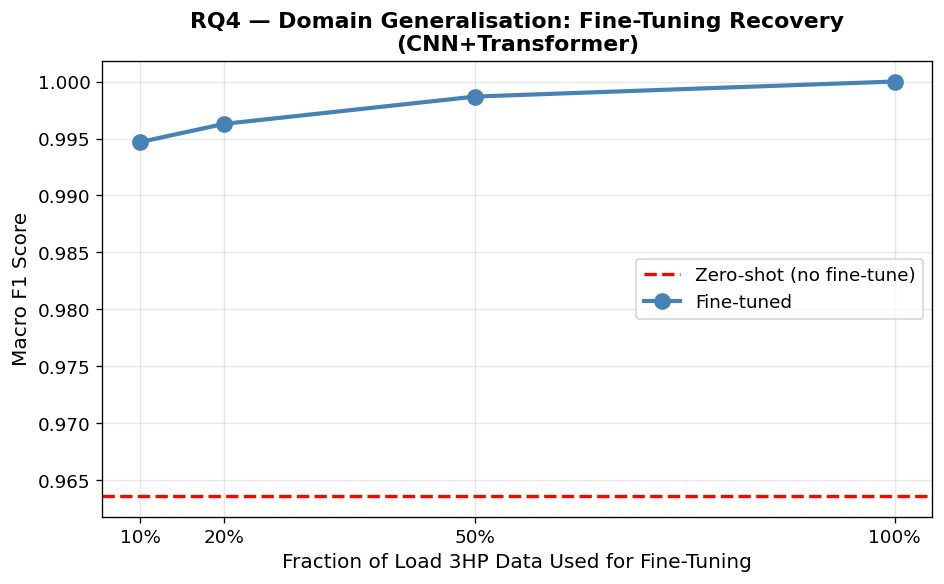

In [13]:
# Zero-shot = already measured (model trained on loads 0+2, tested on load 3)
zero_shot_f1 = dl_models[best_name]['f1']
print(f'Zero-shot Macro F1 (no fine-tuning): {zero_shot_f1:.4f}')

# Fine-tune using increasing fractions of load 3 HP data
fractions = [0.10, 0.20, 0.50, 1.00]
ft_results = []

# Select the best model class to fine-tune
model_builders = {
    '1D CNN':         build_cnn,
    'CNN+LSTM':       build_cnn_lstm,
    'CNN+Transformer':build_cnn_transformer
}
best_builder = model_builders[best_name]
best_trained = {'1D CNN': cnn_model, 'CNN+LSTM': lstm_model,
                'CNN+Transformer': transformer_model}[best_name]

for frac in fractions:
    n_samples = max(1, int(len(X_test_dl) * frac))
    idx_ft    = np.random.choice(len(X_test_dl), n_samples, replace=False)
    X_ft, y_ft = X_test_dl[idx_ft], y_test[idx_ft]

    # Clone best model and load trained weights
    ft_model = best_builder()
    ft_model.set_weights(best_trained.get_weights())

    # Freeze all layers except the last 3
    for layer in ft_model.layers[:-3]:
        layer.trainable = False
    ft_model.compile(optimizer=keras.optimizers.Adam(1e-4),
                     loss='sparse_categorical_crossentropy', metrics=['accuracy'])

    ft_model.fit(X_ft, y_ft, epochs=10, batch_size=32, verbose=0)

    ft_pred = np.argmax(ft_model.predict(X_test_dl, verbose=0), axis=1)
    ft_f1   = f1_score(y_test, ft_pred, average='macro')
    ft_results.append({'Fraction': frac, 'N Samples': n_samples, 'Macro F1': ft_f1})
    print(f'  Fine-tune {int(frac*100):3d}% ({n_samples:4d} samples) → Macro F1 = {ft_f1:.4f}')

df_ft = pd.DataFrame(ft_results)
df_ft.to_csv(f'{RESULTS_DIR}/rq4_finetuning.csv', index=False)

# Plot
fig, ax = plt.subplots(figsize=(8, 5))
ax.axhline(zero_shot_f1, linestyle='--', color='red', linewidth=2, label='Zero-shot (no fine-tune)')
ax.plot(df_ft['Fraction'], df_ft['Macro F1'],
        marker='o', linewidth=2.5, markersize=9, color='steelblue', label='Fine-tuned')
ax.set_xlabel('Fraction of Load 3HP Data Used for Fine-Tuning', fontsize=12)
ax.set_ylabel('Macro F1 Score', fontsize=12)
ax.set_title(f'RQ4 — Domain Generalisation: Fine-Tuning Recovery\n({best_name})', fontweight='bold')
ax.set_xticks(fractions)
ax.set_xticklabels([f'{int(f*100)}%' for f in fractions])
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(f'{RESULTS_DIR}/rq4_finetuning.png', bbox_inches='tight')
plt.show()

---
## Section 10 — Final Summary & Inference Demo

In [14]:
print('=' * 65)
print('FINAL RESULTS SUMMARY')
print('=' * 65)
print('\n--- RQ1 & RQ2: Model Comparison (Test = Load 3HP) ---')
print(df_results.to_string(index=False))
print(f'\n--- RQ3: Per-class Accuracy by Severity ({best_name}) ---')
print(df_sev[['Label','Severity (mils)','Accuracy','Count']].to_string(index=False))
print(f'\n--- RQ4: Fine-Tuning Recovery ({best_name}) ---')
print(f'Zero-shot Macro F1: {zero_shot_f1:.4f}')
print(df_ft.to_string(index=False))

FINAL RESULTS SUMMARY

--- RQ1 & RQ2: Model Comparison (Test = Load 3HP) ---
          Model  Accuracy  Macro F1 Parameters  Latency (ms)
  Random Forest  0.933541  0.916736        N/A           NaN
            SVM  0.927539  0.916595        N/A           NaN
         1D CNN  0.888864  0.849322     464112     42.884979
       CNN+LSTM  0.851300  0.809000     283728     47.321446
CNN+Transformer  0.969549  0.963638     483216     80.088005

--- RQ3: Per-class Accuracy by Severity (CNN+Transformer) ---
   Label  Severity (mils)  Accuracy  Count
  Normal                0  1.000000    947
    IR_7                7  1.000000    239
   IR_14               14  0.927966    236
   IR_21               21  1.000000    237
   IR_28               28  1.000000    236
  Ball_7                7  0.995763    236
 Ball_14               14  1.000000    237
 Ball_21               21  0.582278    237
 Ball_28               28  1.000000    235
  OR@6_7                7  1.000000    238
 OR@6_14             

In [15]:
# ── Inference demo: predict on a single new window ──────────────────────────
# Simulates what would happen in a real deployment scenario

def predict_single_window(model, raw_window, all_labels, top_k=3):
    """
    Takes a single raw 1024-sample window, normalises it,
    and returns the top-k predicted fault classes with confidence.
    """
    # Step 1: z-score normalise
    mean, std = raw_window.mean(), raw_window.std()
    norm = (raw_window - mean) / (std + 1e-8)

    # Step 2: reshape to (1, 1024, 1)
    tensor = norm.reshape(1, -1, 1).astype(np.float32)

    # Step 3: predict
    probs = model.predict(tensor, verbose=0)[0]

    # Step 4: top-k results
    top_idx = np.argsort(probs)[::-1][:top_k]
    return [(all_labels[i], float(probs[i])) for i in top_idx]

# Test on 5 random windows from test set
best_model_obj = {'1D CNN': cnn_model, 'CNN+LSTM': lstm_model,
                  'CNN+Transformer': transformer_model}[best_name]

print(f'Inference demo — {best_name}')
print(f'{"True label":<16} {"Top prediction":<16} {"Confidence":<12} {"Correct?"}')
print('-' * 58)

for i in np.random.choice(len(X_test_dl), 10, replace=False):
    raw_win  = X_test_dl[i, :, 0]   # already normalised — use as-is for demo
    true_lbl = ALL_LABELS[y_test[i]]
    preds    = predict_single_window(best_model_obj, raw_win, ALL_LABELS)
    top_pred, top_conf = preds[0]
    correct  = '✓' if top_pred == true_lbl else '✗'
    print(f'{true_lbl:<16} {top_pred:<16} {top_conf:.3f}        {correct}')

print('\nAll result files saved to:', RESULTS_DIR)
for f in sorted(os.listdir(RESULTS_DIR)):
    print(f'  {f}')

Inference demo — CNN+Transformer
True label       Top prediction   Confidence   Correct?
----------------------------------------------------------
OR@6_14          OR@6_14          1.000        ✓
Normal           Normal           1.000        ✓
Ball_28          Ball_28          1.000        ✓
IR_7             IR_7             1.000        ✓
OR@12_21         OR@12_21         1.000        ✓
IR_21            IR_21            1.000        ✓
Ball_21          Ball_14          0.843        ✗
Normal           Normal           1.000        ✓
IR_14            IR_14            0.994        ✓
IR_28            IR_28            1.000        ✓

All result files saved to: results
  model_comparison.csv
  rq1_feature_importance.png
  rq1_rq2_comparison.png
  rq2_confusion_matrix.png
  rq3_severity.csv
  rq3_severity_accuracy.png
  rq4_finetuning.csv
  rq4_finetuning.png
  training_curves.png
